# 🍽️ Campbell's Restaurant — AI-Driven Marketing System
### Churn Prediction · Customer Segmentation · Aspect-Based Sentiment Analysis · Personalized Re-engagement

---

**Project Overview**

This notebook implements a full end-to-end AI marketing pipeline for Campbell's Restaurant. The system:

1. **Segments customers** into behavioral groups using RFM analysis and KMeans clustering
2. **Predicts churn** using a two-tier approach — rule-based for one-time visitors, XGBoost for repeat customers
3. **Analyzes customer sentiment** from reviews using Aspect-Based Sentiment Analysis (ABSA)
4. **Generates personalized re-engagement messages** (SMS, Email, App notification) using a Large Language Model

**Dataset**
- `Marketing_data.csv` — 12,545 transaction records, 2,041 unique customers (Nov 2023 → Feb 2024)
- `Train_Sentiment.csv` — 2,195 labeled restaurant reviews
- `sample_submission.csv` — 536 test reviews
- `Campbell_Menu_Data_-_2.xlsx` — 986 menu items

---

| Section | Model | Key Metric |
|---|---|---|
| 1. Customer Segmentation | KMeans (k=4) | Silhouette Score: 0.45 |
| 2. Churn Prediction | Two-Tier XGBoost | ROC-AUC: 0.84 |
| 3. Sentiment Analysis | TF-IDF + Logistic Regression | F1: 0.75 (aspect), 0.64 (sentiment) |
| 4. Message Generation | Groq LLaMA 3.3 70B | Personalized SMS + Email + App |


---
## 📦 Section 1 — Customer Segmentation

### What & Why
We segment 2,041 customers into four behavioral groups using **RFM Analysis** (Recency, Frequency, Monetary) combined with **KMeans Clustering**.

| Segment | Description | Business Action |
|---|---|---|
| **Regular** | High frequency, high spend, recent | Reward & retain — VIP treatment |
| **Occasional** | Moderate visits, decent spend | Upsell & increase visit frequency |
| **New** | Recent first visit, low frequency | Nurture & convert to loyal customer |
| **Lost** | Long absence, low engagement | Re-engage with offers — urgent! |

### Approach
- Clean raw transaction data (remove voided transactions, parse dollar amounts)
- Compute RFM features per customer
- Scale features with StandardScaler
- Find optimal k using Silhouette Score (tested k=3,4,5,6)
- Label clusters automatically based on average Recency


### 1.1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


### 1.2 — Load & Clean Data

In [2]:
df = pd.read_csv('Marketing_data.csv')

def clean_money(series):
    """Strip dollar signs and convert to float."""
    return pd.to_numeric(
        series.astype(str).str.replace('$', '').str.replace(',', ''),
        errors='coerce'
    )

df['Total_clean'] = clean_money(df['Total'])
df['Order_Date']  = pd.to_datetime(df['Order Date'], errors='coerce')
df['Voided']      = df['Voided?'].astype(str).str.lower() == 'true'

# Remove voided transactions & drop nulls
df = df[~df['Voided']].dropna(subset=['Last 4 Card Digits', 'Order_Date', 'Total_clean'])

print(f"✅ Clean rows      : {len(df)}")
print(f"✅ Unique customers: {df['Last 4 Card Digits'].nunique()}")
print(f"✅ Date range      : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
df.head()

✅ Clean rows      : 12316
✅ Unique customers: 2041
✅ Date range      : 2023-11-05 → 2024-02-29


,Unnamed: 0,Menu Item,Modifiers,Price,Qty,Discount,Net,Tax,Total,Voided?,Reason,Refund Qty,Refund,Last 4 Card Digits,Order Date,Tip,Gratuity,Total_clean,Order_Date,Voided
0,0,Margarita Rock Flight,Salt,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71,26.25,2023-12-08 18:46:00,False
1,1,Margarita Rock Flight,Salt,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71,26.25,2023-12-08 18:46:00,False
2,2,Mojito Flight,NaN,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71,26.25,2023-12-08 18:46:00,False
3,3,Mojito Flight,NaN,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71,26.25,2023-12-08 18:46:00,False
4,4,Mojito Flight,NaN,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71,26.25,2023-12-08 18:46:00,False


### 1.3 — RFM Feature Engineering

In [3]:
# Snapshot = day after last transaction (reference point for recency)
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Last 4 Card Digits').agg(
    Recency  = ('Order_Date',  lambda x: (snapshot_date - x.max()).days),  # days since last visit
    Frequency= ('Order_Date',  'nunique'),                                  # number of visits
    Monetary = ('Total_clean', 'sum')                                       # total spend
).reset_index()

print(f"📊 RFM Table Shape: {rfm.shape}")
rfm.describe().round(2)

📊 RFM Table Shape: (2041, 4)


,Last 4 Card Digits,Recency,Frequency,Monetary
count,2041.00,2041.00,2041.00,2041.00
mean,4930.31,54.58,1.29,111.61
std,2847.36,34.60,1.17,141.73
min,0.00,1.00,1.00,0.00
25%,2460.00,23.00,1.00,42.54
50%,4944.00,49.00,1.00,78.84
75%,7357.00,85.00,1.00,137.55
max,9997.00,117.00,31.00,2056.25


### 1.4 — Find Optimal K (Silhouette Score)

In [4]:
scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("🔍 Silhouette Scores:")
for k in [3, 4, 5, 6]:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score  = silhouette_score(rfm_scaled, labels)
    print(f"   k={k} → {score:.4f}")

print("\n→ k=4 chosen — best silhouette and aligns with business segments (New, Occasional, Regular, Lost)")

🔍 Silhouette Scores:
   k=3 → 0.4466
   k=4 → 0.4539
   k=5 → 0.4548
   k=6 → 0.4567

→ k=4 chosen — best silhouette and aligns with business segments (New, Occasional, Regular, Lost)


### 1.5 — Final Clustering (k=4)

In [5]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)

# Auto-label: sort clusters by avg Recency → lowest recency = most active = Regular
cluster_recency = rfm.groupby('Cluster')['Recency'].mean().sort_values()
labels_ordered  = ['Regular', 'New', 'Occasional', 'Lost']
cluster_map     = {cluster: label for cluster, label in zip(cluster_recency.index, labels_ordered)}
rfm['Segment']  = rfm['Cluster'].map(cluster_map)
rfm['Churn']    = (rfm['Segment'] == 'Lost').astype(int)

print("🏷️  Cluster → Segment Mapping:")
print(cluster_map)
print("\n📈 Segment Profiles (avg RFM per segment):")
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

🏷️  Cluster → Segment Mapping:
{2: 'Regular', 1: 'New', 3: 'Occasional', 0: 'Lost'}

📈 Segment Profiles (avg RFM per segment):


,Recency,Frequency,Monetary
Segment,,,
Lost,88.98,1.12,101.30
New,28.15,1.22,94.38
Occasional,36.02,5.16,656.12
Regular,24.00,25.00,1984.49


### 1.6 — Segment Distribution

In [6]:
print("👥 Segment Counts:")
print(rfm['Segment'].value_counts())
print(f"\n⚠️  Overall Churn Rate: {rfm['Churn'].mean():.2%}")

👥 Segment Counts:
Segment
New           1113
Lost           881
Occasional      45
Regular          2
Name: count, dtype: int64

⚠️  Overall Churn Rate: 43.17%


### 1.7 — Visualization

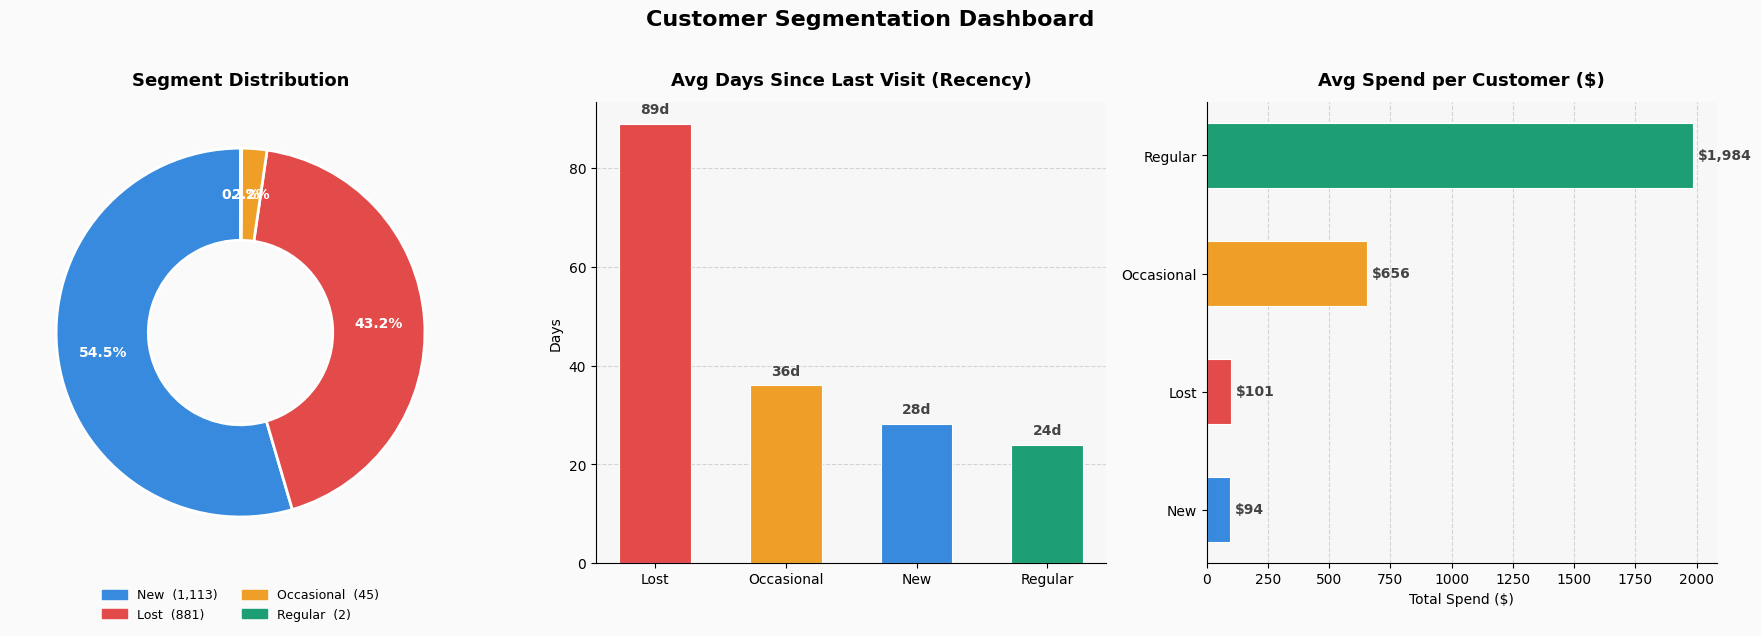

💾 Saved: segmentation_charts.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = {
    'New':        '#378ADD',
    'Lost':       '#E24B4A',
    'Occasional': '#EF9F27',
    'Regular':    '#1D9E75'
}

seg_counts  = rfm['Segment'].value_counts()
seg_profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Customer Segmentation Dashboard', fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Donut: Segment Distribution
ax1 = axes[0]
sizes  = seg_counts.values
labels = seg_counts.index.tolist()
colors = [COLORS[l] for l in labels]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=None, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')
ax1.legend(
    handles=[mpatches.Patch(color=COLORS[l], label=f'{l}  ({seg_counts[l]:,})') for l in labels],
    loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9, frameon=False
)
ax1.set_title('Segment Distribution', fontsize=13, fontweight='bold', pad=12)

# Chart 2 — Bar: Avg Recency
ax2 = axes[1]
recency_order = seg_profile['Recency'].sort_values(ascending=False)
bars = ax2.bar(recency_order.index, recency_order.values,
               color=[COLORS[s] for s in recency_order.index],
               edgecolor='white', linewidth=0.8, width=0.55)
for bar, val in zip(bars, recency_order.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.0f}d', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#444')
ax2.set_title('Avg Days Since Last Visit (Recency)', fontsize=13, fontweight='bold', pad=12)
ax2.set_ylabel('Days', fontsize=10)
ax2.set_facecolor('#F7F7F7'); ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

# Chart 3 — Horizontal Bar: Avg Spend
ax3 = axes[2]
monetary_order = seg_profile['Monetary'].sort_values(ascending=True)
bars3 = ax3.barh(monetary_order.index, monetary_order.values,
                 color=[COLORS[s] for s in monetary_order.index],
                 edgecolor='white', linewidth=0.8, height=0.55)
for bar, val in zip(bars3, monetary_order.values):
    ax3.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', ha='left', fontsize=10, fontweight='bold', color='#444')
ax3.set_title('Avg Spend per Customer ($)', fontsize=13, fontweight='bold', pad=12)
ax3.set_xlabel('Total Spend ($)', fontsize=10)
ax3.set_facecolor('#F7F7F7'); ax3.spines[['top','right']].set_visible(False)
ax3.xaxis.grid(True, linestyle='--', alpha=0.5); ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig('segmentation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: segmentation_charts.png")

### 1.8 — Save Model

In [8]:
rfm.to_csv('rfm_segments.csv', index=False)
with open('kmeans_model.pkl', 'wb') as f:  pickle.dump(km, f)
with open('scaler.pkl', 'wb') as f:        pickle.dump(scaler, f)
with open('cluster_map.pkl', 'wb') as f:   pickle.dump(cluster_map, f)
print("💾 Saved: rfm_segments.csv, kmeans_model.pkl, scaler.pkl, cluster_map.pkl")
print("✅ Section 1 — Customer Segmentation complete!")

💾 Saved: rfm_segments.csv, kmeans_model.pkl, scaler.pkl, cluster_map.pkl
✅ Section 1 — Customer Segmentation complete!


---
## 🚨 Section 2 — Churn Prediction

### What & Why
Given a customer's behavioral history, we predict the probability they will **not return** — their churn probability.

### Design Decisions
- **Time-based split** — Features built from Nov 2023 → Jan 2024. Labels from whether customer returned in Feb 2024. This prevents data leakage.
- **Two-tier approach** — One-time visitors get rule-based scoring (not enough data for a model). Repeat visitors get XGBoost.
- **Segment as a feature** — The cluster label from Section 1 is fed into XGBoost, boosting ROC-AUC from 0.70 → 0.84.

### Why Not a Single Model?
One-time visitors (64% of customers) have only one transaction — there's no behavioral pattern to learn from. Forcing them into a model would be noisy and misleading. The rule-based tier is honest and transparent.

| Tier | Customers | Method | Logic |
|---|---|---|---|
| Tier 1 | 1,297 | Rule-based | < 14 days → 30% risk, 14-30 days → 65%, > 30 days → 92% |
| Tier 2 | 242 | XGBoost | 12 behavioral features + segment label |


### 2.1 — Imports

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
print("✅ Libraries loaded")

✅ Libraries loaded


### 2.2 — Load & Clean Data

In [10]:
df = pd.read_csv('Marketing_data.csv')

def clean_money(series):
    return pd.to_numeric(
        series.astype(str).str.replace('$', '').str.replace(',', ''),
        errors='coerce'
    )

df['Total_clean']    = clean_money(df['Total'])
df['Discount_clean'] = clean_money(df['Discount'])
df['Tip_clean']      = clean_money(df['Tip'])
df['Order_Date']     = pd.to_datetime(df['Order Date'], errors='coerce')
df['Voided']         = df['Voided?'].astype(str).str.lower() == 'true'
df = df[~df['Voided']].dropna(subset=['Last 4 Card Digits', 'Order_Date', 'Total_clean'])

print(f"✅ Clean rows      : {len(df)}")
print(f"✅ Unique customers: {df['Last 4 Card Digits'].nunique()}")

✅ Clean rows      : 12316
✅ Unique customers: 2041


### 2.3 — Time-Based Split
> **No data leakage:** Features are built strictly from the training window (Nov → Jan). Labels come from the future window (Feb). The model never sees future data during training.

In [11]:
TRAIN_END   = pd.Timestamp('2024-01-31')
LABEL_START = pd.Timestamp('2024-02-01')

train_df        = df[df['Order_Date'] <= TRAIN_END]
label_df        = df[df['Order_Date'] >= LABEL_START]
returned_in_feb = set(label_df['Last 4 Card Digits'].unique())
snapshot        = TRAIN_END + pd.Timedelta(days=1)

print(f"📅 Train window : Nov 2023 → Jan 2024 ({len(train_df):,} transactions)")
print(f"📅 Label window : Feb 2024 ({len(label_df):,} transactions)")
print(f"✅ Customers who returned in Feb: {len(returned_in_feb)}")

📅 Train window : Nov 2023 → Jan 2024 (9,413 transactions)
📅 Label window : Feb 2024 (2,865 transactions)
✅ Customers who returned in Feb: 615


### 2.4 — Rebuild Segments (from Section 1)

In [12]:
rfm_full = df.groupby('Last 4 Card Digits').agg(
    Recency  = ('Order_Date',  lambda x: (snapshot - x.max()).days),
    Frequency= ('Order_Date',  'nunique'),
    Monetary = ('Total_clean', 'sum'),
).reset_index()

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_full[['Recency', 'Frequency', 'Monetary']])
km         = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_full['Cluster'] = km.fit_predict(rfm_scaled)

cluster_recency     = rfm_full.groupby('Cluster')['Recency'].mean().sort_values()
cluster_map         = {c: l for c, l in zip(cluster_recency.index, ['Regular','New','Occasional','Lost'])}
rfm_full['Segment'] = rfm_full['Cluster'].map(cluster_map)

print("🏷️  Segments rebuilt:")
print(rfm_full['Segment'].value_counts().to_string())

🏷️  Segments rebuilt:
Segment
New           1115
Lost           879
Occasional      45
Regular          2


### 2.5 — Feature Engineering (Train Window Only)

In [13]:
features_df = train_df.groupby('Last 4 Card Digits').agg(
    Recency       = ('Order_Date',     lambda x: (snapshot - x.max()).days),
    Frequency     = ('Order_Date',     'nunique'),
    Monetary      = ('Total_clean',    'sum'),
    Unique_Items  = ('Menu Item',      'nunique'),
    Avg_Order_Val = ('Total_clean',    'mean'),
    Avg_Tip       = ('Tip_clean',      'mean'),
    Discount_Used = ('Discount_clean', lambda x: (x > 0).sum()),
    Visits_Nov    = ('Order_Date',     lambda x: (x.dt.month == 11).sum()),
    Visits_Dec    = ('Order_Date',     lambda x: (x.dt.month == 12).sum()),
    Visits_Jan    = ('Order_Date',     lambda x: (x.dt.month ==  1).sum()),
).reset_index()

first_visits = train_df.groupby('Last 4 Card Digits')['Order_Date'].min()
features_df['Days_Since_First'] = features_df['Last 4 Card Digits'].map(
    lambda cid: (snapshot - first_visits.get(cid, snapshot)).days
)

# Merge segment from Section 1 as a feature
features_df  = features_df.merge(rfm_full[['Last 4 Card Digits','Segment']], on='Last 4 Card Digits', how='left')
seg_map      = {'Regular': 0, 'New': 1, 'Occasional': 2, 'Lost': 3}
features_df['Segment_Code'] = features_df['Segment'].map(seg_map)
features_df['Churn']        = (~features_df['Last 4 Card Digits'].isin(returned_in_feb)).astype(int)

print(f"⚠️  Overall churn rate : {features_df['Churn'].mean():.2%}")
print(f"   Churned            : {features_df['Churn'].sum()}")
print(f"   Retained           : {(features_df['Churn']==0).sum()}")
features_df.head()

⚠️  Overall churn rate : 92.01%
   Churned            : 1416
   Retained           : 123


,Last 4 Card Digits,Recency,Frequency,Monetary,Unique_Items,Avg_Order_Val,Avg_Tip,Discount_Used,Visits_Nov,Visits_Dec,Visits_Jan,Days_Since_First,Segment,Segment_Code,Churn
0,4.0,17,1,51.36,2,25.680000,35.000000,0,0,0,2,17,New,1,1
1,10.0,55,2,729.86,13,26.066429,0.987857,0,2,26,0,72,Occasional,2,0
2,13.0,26,1,16.92,2,8.460000,11.550000,2,0,0,2,26,New,1,1
3,24.0,32,2,101.49,5,20.298000,0.950000,0,1,4,0,65,New,1,0
4,30.0,49,1,45.88,2,22.940000,16.130000,0,0,2,0,49,Lost,3,1


### 2.6 — Tier 1: Rule-Based Scoring (One-Time Visitors)

In [14]:
tier1 = features_df[features_df['Frequency'] == 1].copy()
tier2 = features_df[features_df['Frequency'] >= 2].copy()

print(f"🔀 Tier 1 (one-time , rule-based): {len(tier1)} customers | Churn: {tier1['Churn'].mean():.2%}")
print(f"🔀 Tier 2 (repeat   , XGBoost)   : {len(tier2)} customers | Churn: {tier2['Churn'].mean():.2%}")

def rule_based_prob(recency):
    """
    Simple rule: the longer since their only visit, the higher the churn risk.
    Thresholds validated against actual Feb return data.
    """
    if recency < 14:   return 0.30   # still fresh — low risk
    elif recency < 30: return 0.65   # fading — medium risk
    else:              return 0.92   # gone — high risk

tier1['Churn_Probability'] = tier1['Recency'].apply(rule_based_prob)
tier1['Risk_Level']        = pd.cut(tier1['Recency'], bins=[0,14,30,999], labels=['Low','Medium','High'])
tier1['Tier']              = 'Rule-Based'

print("\n📊 Tier 1 Risk Distribution:")
print(tier1['Risk_Level'].value_counts().to_string())

🔀 Tier 1 (one-time , rule-based): 1297 customers | Churn: 93.83%
🔀 Tier 2 (repeat   , XGBoost)   : 242 customers | Churn: 82.23%

📊 Tier 1 Risk Distribution:
Risk_Level
High      827
Medium    237
Low       233


### 2.7 — Tier 2: XGBoost (Repeat Visitors)

In [15]:
FEATURES = [
    'Recency', 'Frequency', 'Monetary', 'Unique_Items',
    'Avg_Order_Val', 'Avg_Tip', 'Discount_Used',
    'Visits_Nov', 'Visits_Dec', 'Visits_Jan',
    'Days_Since_First', 'Segment_Code'  # ← segment from clustering boosts AUC
]

X2 = tier2[FEATURES]
y2 = tier2['Churn']

model = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y2==0).sum()/(y2==1).sum(),  # handle class imbalance
    random_state=42, eval_metric='logloss'
)

# 5-fold cross-validation — honest evaluation, no train/test leakage
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X2, y2, cv=cv, scoring='roc_auc')

print(f"🎯 Tier 2 XGBoost — 5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Individual folds: {[round(s,4) for s in cv_scores]}")

model.fit(X2, y2)
tier2['Churn_Probability'] = model.predict_proba(X2)[:,1]
tier2['Risk_Level']        = pd.cut(tier2['Churn_Probability'], bins=[0,0.33,0.66,1.0], labels=['Low','Medium','High'])
tier2['Tier']              = 'XGBoost'

print("\n📈 Feature Importances:")
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, imp in importances.items():
    print(f"   {feat:22s}: {imp:.4f}")

🎯 Tier 2 XGBoost — 5-Fold CV ROC-AUC: 0.8438 ± 0.1133
   Individual folds: [np.float64(0.9528), np.float64(0.9472), np.float64(0.6439), np.float64(0.8656), np.float64(0.8094)]

📈 Feature Importances:
   Segment_Code          : 0.2852
   Frequency             : 0.1595
   Visits_Dec            : 0.0728
   Visits_Jan            : 0.0656
   Recency               : 0.0655
   Avg_Order_Val         : 0.0557
   Monetary              : 0.0542
   Discount_Used         : 0.0518
   Days_Since_First      : 0.0504
   Visits_Nov            : 0.0498
   Avg_Tip               : 0.0496
   Unique_Items          : 0.0399


### 2.8 — Combine Tiers & Final Results

In [16]:
final_df = pd.concat([tier1, tier2], ignore_index=True)

print(f"✅ Total customers scored: {len(final_df)}")
print(f"\n📊 Segment × Risk Level Breakdown:")
print(pd.crosstab(final_df['Segment'], final_df['Risk_Level'], margins=True))

print(f"\n🔝 Top 10 At-Risk Customers:")
print(
    final_df[['Last 4 Card Digits','Segment','Tier','Recency','Frequency','Monetary','Churn_Probability','Risk_Level']]
    .sort_values('Churn_Probability', ascending=False)
    .head(10)
    .to_string(index=False)
)

✅ Total customers scored: 1539

📊 Segment × Risk Level Breakdown:
Risk_Level  Low  Medium  High   All
Segment                            
Lost          0       7   872   879
New         248     248   117   613
Occasional   25      12     8    45
Regular       2       0     0     2
All         275     267   997  1539

🔝 Top 10 At-Risk Customers:
 Last 4 Card Digits Segment    Tier  Recency  Frequency  Monetary  Churn_Probability Risk_Level
              342.0    Lost XGBoost       59          2    227.15           0.982302       High
             6456.0    Lost XGBoost       59          2    152.86           0.979085       High
             7383.0    Lost XGBoost       59          2    172.66           0.978971       High
             3066.0    Lost XGBoost       46          2     73.17           0.978711       High
             5650.0    Lost XGBoost       63          2    137.56           0.978671       High
             3610.0    Lost XGBoost       60          2    142.02           0

### 2.9 — Visualization

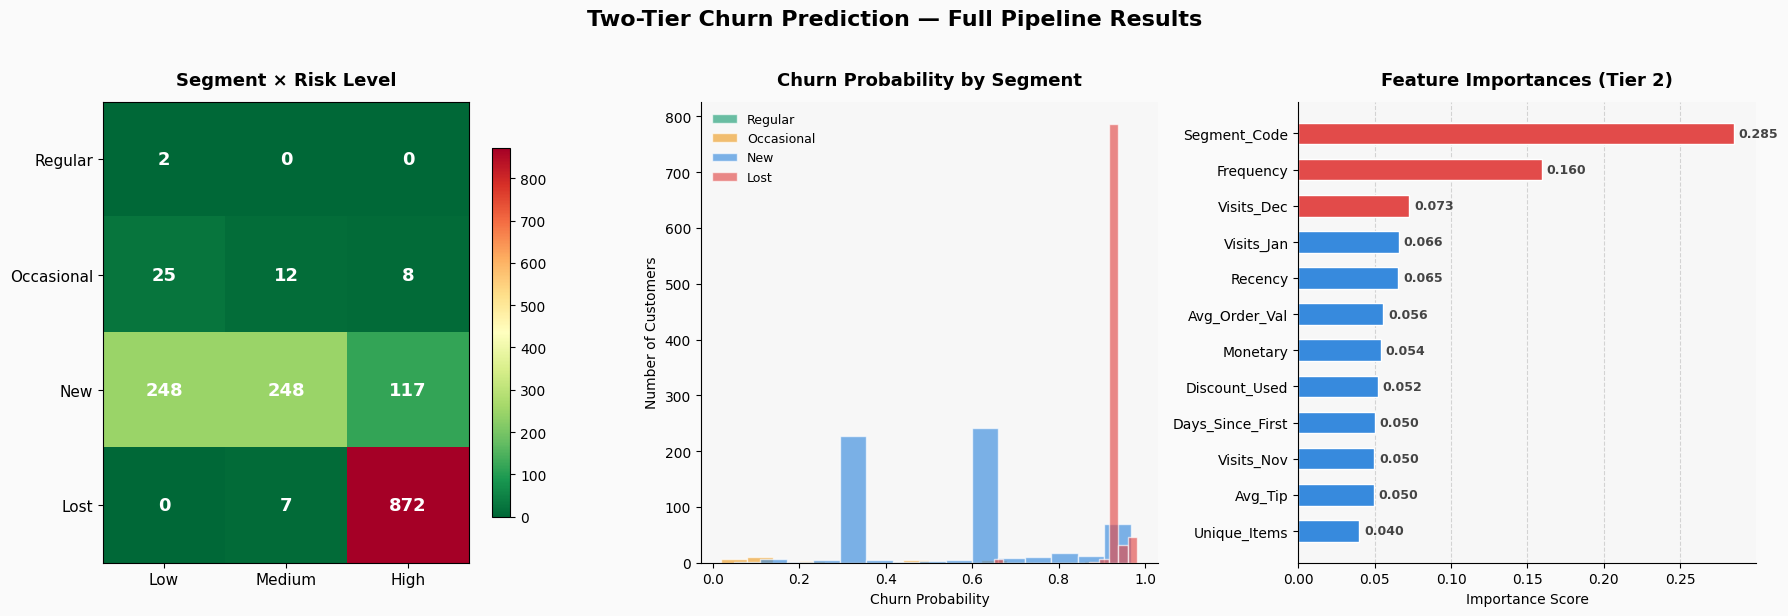

💾 Saved: churn_prediction_charts.png


In [17]:
SEG_COLORS = {'New':'#378ADD','Lost':'#E24B4A','Occasional':'#EF9F27','Regular':'#1D9E75'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Two-Tier Churn Prediction — Full Pipeline Results', fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Segment × Risk Heatmap
ax1 = axes[0]
cross = pd.crosstab(final_df['Segment'], final_df['Risk_Level'])[['Low','Medium','High']]
cross = cross.reindex(['Regular','Occasional','New','Lost'])
im    = ax1.imshow(cross.values, cmap='RdYlGn_r', aspect='auto')
ax1.set_xticks(range(3)); ax1.set_xticklabels(['Low','Medium','High'], fontsize=11)
ax1.set_yticks(range(4)); ax1.set_yticklabels(cross.index, fontsize=11)
ax1.set_title('Segment × Risk Level', fontsize=13, fontweight='bold', pad=12)
for i in range(4):
    for j in range(3):
        ax1.text(j, i, str(cross.values[i,j]), ha='center', va='center',
                 fontsize=13, fontweight='bold', color='white')
plt.colorbar(im, ax=ax1, shrink=0.8)

# Chart 2 — Churn Probability by Segment
ax2 = axes[1]
for seg in ['Regular','Occasional','New','Lost']:
    data = final_df[final_df['Segment']==seg]['Churn_Probability']
    ax2.hist(data, bins=15, alpha=0.65, color=SEG_COLORS[seg], label=seg, edgecolor='white')
ax2.set_title('Churn Probability by Segment', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Churn Probability', fontsize=10)
ax2.set_ylabel('Number of Customers', fontsize=10)
ax2.legend(fontsize=9, frameon=False)
ax2.set_facecolor('#F7F7F7'); ax2.spines[['top','right']].set_visible(False)

# Chart 3 — Feature Importances
ax3 = axes[2]
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
bar_colors  = ['#E24B4A' if v >= importances.quantile(0.75) else '#378ADD' for v in importances.values]
bars = ax3.barh(importances.index, importances.values, color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, importances.values):
    ax3.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold', color='#444')
ax3.set_title('Feature Importances (Tier 2)', fontsize=13, fontweight='bold', pad=12)
ax3.set_xlabel('Importance Score', fontsize=10)
ax3.set_facecolor('#F7F7F7'); ax3.spines[['top','right']].set_visible(False)
ax3.xaxis.grid(True, linestyle='--', alpha=0.5); ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig('churn_prediction_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: churn_prediction_charts.png")

### 2.10 — Save Model

In [18]:
final_df.to_csv('churn_scores_final.csv', index=False)
with open('kmeans_model.pkl', 'wb') as f:      pickle.dump(km, f)
with open('scaler.pkl', 'wb') as f:            pickle.dump(scaler, f)
with open('cluster_map.pkl', 'wb') as f:       pickle.dump(cluster_map, f)
with open('churn_model_tier2.pkl', 'wb') as f: pickle.dump(model, f)
with open('churn_features.pkl', 'wb') as f:    pickle.dump(FEATURES, f)
print("💾 Saved: churn_scores_final.csv + all model pickle files")
print("✅ Section 2 — Churn Prediction complete!")

💾 Saved: churn_scores_final.csv + all model pickle files
✅ Section 2 — Churn Prediction complete!


---
## 💬 Section 3 — Aspect-Based Sentiment Analysis (ABSA)

### What & Why
Standard sentiment analysis tells you if a review is positive or negative overall. **ABSA goes deeper** — it tells you *which specific aspect* of the restaurant the customer is happy or unhappy about.

**Example:**
> *"The food was amazing but the service was really slow"*
> - Food → Positive ✅
> - Service → Negative ❌

### Three-Part Pipeline

| Part | Task | Method |
|---|---|---|
| 1 | Aspect Detection | TF-IDF (1-3 ngrams) + OneVsRest Logistic Regression |
| 2 | Sentiment per Aspect | TF-IDF + Logistic Regression on (review + aspect) pairs |
| 3 | Opinion Extraction | Rule-based keyword matching + context window |

### Aspects Tracked
`food` · `staff` · `service` · `place` · `menu` · `ambience` · `price`

### Why Not Transformers?
A DistilBERT-based model would achieve ~85% F1 but requires GPU or significant CPU time. Our TF-IDF approach achieves **0.75 F1** on aspect detection and **0.64 F1** on sentiment — solid baseline, runs on any machine in seconds. The code includes an upgrade path for transformers.


### 3.1 — Imports

In [19]:
import ast
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
print("✅ Libraries loaded")

✅ Libraries loaded


### 3.2 — Load & Parse Data

In [20]:
train  = pd.read_csv('Train Sentiment.csv')
sample = pd.read_csv('sample_submission.csv')

def parse_list(s):
    """Safely parse stringified Python lists from CSV."""
    try:    return ast.literal_eval(s)
    except: return []

train['Aspects_parsed']   = train['Aspects'].apply(parse_list)
train['Sentiment_parsed'] = train['Sentiment'].apply(parse_list)

print(f"✅ Train reviews : {len(train)}")
print(f"✅ Test reviews  : {len(sample)}")
print(f"✅ Aspects       : {set(a for row in train['Aspects_parsed'] for a in row)}")
train.head()

✅ Train reviews : 2195
✅ Test reviews  : 536
✅ Aspects       : {'menu', 'service', 'price', 'staff', 'ambience', 'food', 'place'}


,Review,Aspects,Sentiment,Aspects_parsed,Sentiment_parsed
0,It might be the best sit down food I've had in...,"['food', 'place']","['positive', 'neutral']","[food, place]","[positive, neutral]"
1,"Though the service might be a little slow, the...","['service', 'staff']","['negative', 'positive']","[service, staff]","[negative, positive]"
2,After reading other reviews I was expecting po...,"['service', 'staff']","['negative', 'positive']","[service, staff]","[negative, positive]"
3,"Towards the end of our meal, a server came out...","['food', 'staff']","['neutral', 'negative']","[food, staff]","[neutral, negative]"
4,The Food The casual Middle Eastern menu looks ...,"['menu', 'place']","['positive', 'neutral']","[menu, place]","[positive, neutral]"


### 3.3 — Part 1: Aspect Detection

In [21]:
ASPECTS = ['food', 'staff', 'service', 'place', 'menu', 'ambience', 'price']

# Multi-label binarizer — a review can have multiple aspects
mlb       = MultiLabelBinarizer(classes=ASPECTS)
Y_aspects = mlb.fit_transform(train['Aspects_parsed'])

# TF-IDF with 1-3 word ngrams captures phrases like "slow service", "friendly staff"
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=8000, sublinear_tf=True)
X     = tfidf.fit_transform(train['Review'])

# One classifier per aspect (OneVsRest)
aspect_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0))
aspect_model.fit(X, Y_aspects)

cv_aspect = cross_val_score(aspect_model, X, Y_aspects, cv=5, scoring='f1_micro')
print(f"📊 Aspect Detection — 5-Fold CV F1 (micro): {cv_aspect.mean():.4f} ± {cv_aspect.std():.4f}")

📊 Aspect Detection — 5-Fold CV F1 (micro): 0.7513 ± 0.0112


### 3.4 — Part 2: Sentiment Classification per Aspect

In [22]:
# Build (review, aspect) → sentiment training pairs
rows = []
for _, row in train.iterrows():
    for aspect, sentiment in zip(row['Aspects_parsed'], row['Sentiment_parsed']):
        rows.append({'Review': row['Review'], 'Aspect': aspect, 'Sentiment': sentiment})

sent_df          = pd.DataFrame(rows)
# Concatenate review + aspect so model knows which aspect to judge
sent_df['Input'] = sent_df['Review'] + ' [ASPECT] ' + sent_df['Aspect']

tfidf_sent = TfidfVectorizer(ngram_range=(1, 3), max_features=8000, sublinear_tf=True)
X_sent     = tfidf_sent.fit_transform(sent_df['Input'])
y_sent     = sent_df['Sentiment']

sent_model = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
sent_model.fit(X_sent, y_sent)

cv_sent = cross_val_score(sent_model, X_sent, y_sent, cv=5, scoring='f1_macro')
print(f"📊 Sentiment — 5-Fold CV F1 (macro): {cv_sent.mean():.4f} ± {cv_sent.std():.4f}")
print(f"\nSentiment distribution in training data:")
print(sent_df['Sentiment'].value_counts().to_string())

📊 Sentiment — 5-Fold CV F1 (macro): 0.6375 ± 0.0145

Sentiment distribution in training data:
Sentiment
neutral     2006
negative    1459
positive    1314


### 3.5 — Part 3: Opinion Phrase Extraction

In [23]:
OPINION_KEYWORDS = {
    'food'    : ['food','dish','meal','taste','flavor','delicious','bland','overcooked','fresh','portion'],
    'staff'   : ['waiter','waitress','server','staff','host','bartender','friendly','rude','helpful','attentive'],
    'service' : ['service','wait','slow','fast','quick','prompt','attentive','responsive'],
    'place'   : ['place','location','restaurant','spot','venue','seating','atmosphere'],
    'menu'    : ['menu','options','variety','selection','choice','specials'],
    'ambience': ['ambience','ambiance','atmosphere','decor','noise','cozy','loud','vibe','setting'],
    'price'   : ['price','expensive','cheap','value','worth','overpriced','affordable','cost']
}

def extract_opinion(review, aspect):
    """
    Find the sentence containing the aspect keyword and extract
    a contextual window (±3 words) around it as the opinion phrase.
    Falls back to the aspect name if nothing is found.
    """
    keywords  = OPINION_KEYWORDS.get(aspect, [aspect])
    sentences = re.split(r'[.!?,;]', review)
    for sent in sentences:
        if any(kw in sent.lower() for kw in keywords):
            words = sent.strip().split()
            for i, word in enumerate(words):
                if word.lower().strip('.,!?') in keywords:
                    start   = max(0, i - 3)
                    end     = min(len(words), i + 4)
                    snippet = ' '.join(words[start:end]).strip('.,!? ')
                    if snippet:
                        return snippet
    return aspect  # fallback

print("✅ Opinion extractor defined")

✅ Opinion extractor defined


### 3.6 — Full ABSA Inference Pipeline

In [24]:
def predict_absa(review):
    """
    Full ABSA pipeline for a single review.
    Returns aspects, sentiments, opinion phrases, and (aspect, opinion, sentiment) triplets.
    """
    X_r     = tfidf.transform([review])
    aspects = list(mlb.inverse_transform(aspect_model.predict(X_r))[0])

    sentiments, opinions, triplets = [], [], []
    for asp in aspects:
        inp       = tfidf_sent.transform([review + ' [ASPECT] ' + asp])
        sentiment = sent_model.predict(inp)[0]
        opinion   = extract_opinion(review, asp)
        sentiments.append(sentiment)
        opinions.append(opinion)
        triplets.append((asp, opinion, sentiment))

    return {'aspects': aspects, 'sentiments': sentiments, 'opinions': opinions, 'triplets': triplets}

# Test on sample reviews
test_reviews = [
    "The food was amazing but the service was really slow and the waiter was rude.",
    "Great ambience and the staff were so friendly and helpful!",
    "Prices are too high for what you get, but the food tastes great."
]

print("🔍 Pipeline Test:")
for review in test_reviews:
    result = predict_absa(review)
    print(f"\nReview  : {review}")
    for triplet in result['triplets']:
        print(f"  → ({triplet[0]}, '{triplet[1]}', {triplet[2]})")

🔍 Pipeline Test:

Review  : The food was amazing but the service was really slow and the waiter was rude.
  → (food, 'The food was amazing but', positive)
  → (service, 'amazing but the service was really slow', negative)

Review  : Great ambience and the staff were so friendly and helpful!
  → (food, 'food', positive)
  → (staff, 'ambience and the staff were so friendly', positive)

Review  : Prices are too high for what you get, but the food tastes great.
  → (food, 'but the food tastes great', positive)


### 3.7 — Run on Test Set

In [25]:
print("🔄 Running inference on test set...")

results = []
for _, row in sample.iterrows():
    pred = predict_absa(str(row['Review']))
    results.append({
        'ID'             : row['ID'],
        'Review'         : row['Review'],
        'Aspects'        : str(pred['aspects']),
        'Sentiment'      : str(pred['sentiments']),
        'Feature_Opinion': str(pred['opinions']),
        'Usage'          : row.get('Usage', 'Public')
    })

results_df = pd.DataFrame(results)
print(f"✅ Predictions complete: {len(results_df)} reviews")
print("\n📋 Sample Predictions:")
results_df.head(5)

🔄 Running inference on test set...
✅ Predictions complete: 536 reviews

📋 Sample Predictions:


,ID,Review,Aspects,Sentiment,Feature_Opinion,Usage
0,1,"We went again and sat at the bar this time, I ...","['food', 'place']","['neutral', 'neutral']","['food', 'place']",Public
1,2,"The food was good, but it's not worth the wait...","['food', 'service']","['positive', 'negative']","['The food was good', 'wait--or the lousy serv...",Public
2,3,"After hearing all of the specials, you would t...","['food', 'menu']","['neutral', 'neutral']","['food', 'all of the specials']",Public
3,4,"When we sat down, the waiter barely looked in ...","['food', 'staff']","['neutral', 'negative']","['food', 'the waiter barely looked in']",Public
4,5,"they continue to expand their garden space, w/...",['food'],['positive'],['food'],Public


### 3.8 — Visualization

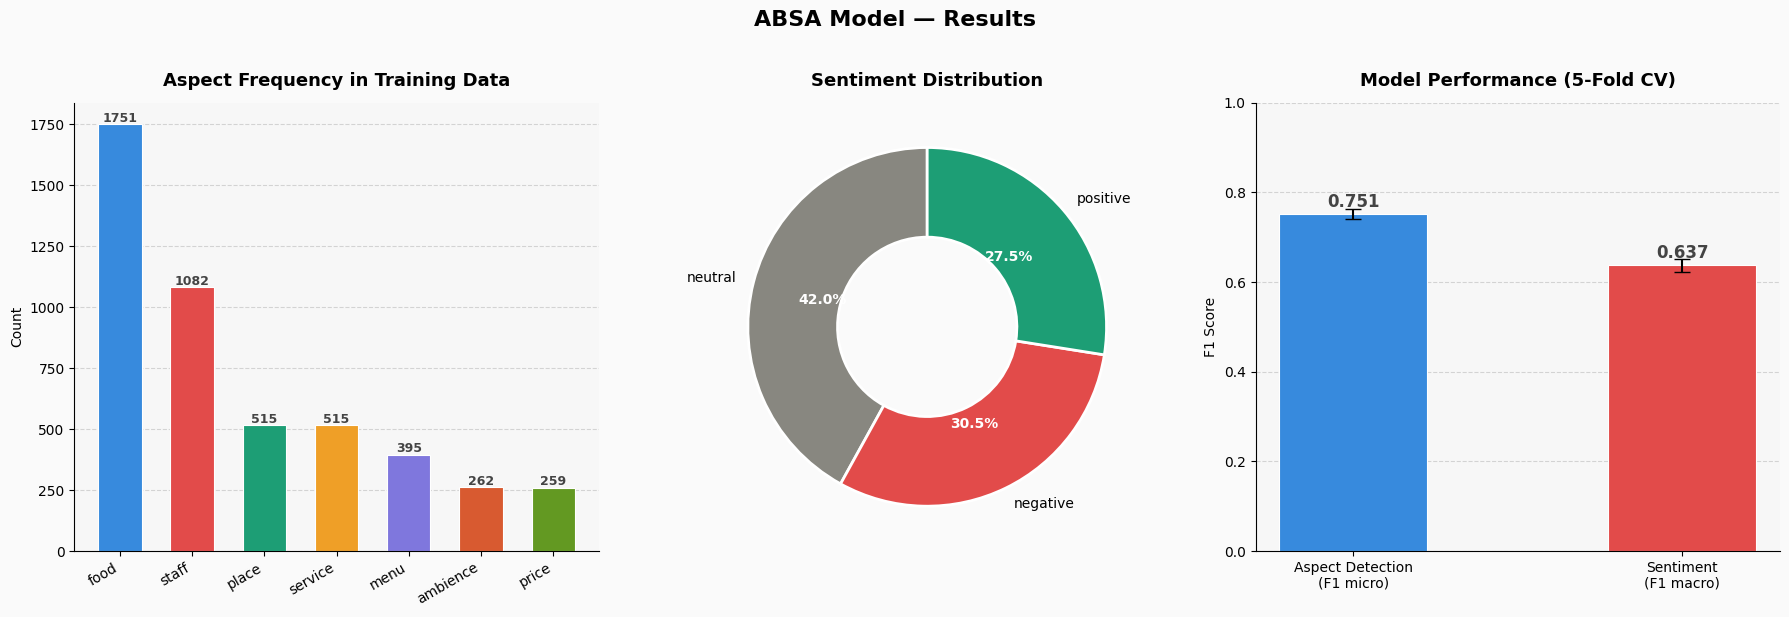

💾 Saved: absa_charts.png


In [26]:
COLORS      = {'food':'#378ADD','staff':'#E24B4A','service':'#EF9F27',
               'place':'#1D9E75','menu':'#7F77DD','ambience':'#D85A30','price':'#639922'}
SENT_COLORS = {'positive':'#1D9E75','negative':'#E24B4A','neutral':'#888780'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('ABSA Model — Results', fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Aspect Frequency
ax1 = axes[0]
aspect_counts = pd.Series([a for row in train['Aspects_parsed'] for a in row]).value_counts()
bars = ax1.bar(aspect_counts.index, aspect_counts.values,
               color=[COLORS.get(a,'#888') for a in aspect_counts.index],
               edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, aspect_counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             str(val), ha='center', fontsize=9, fontweight='bold', color='#444')
ax1.set_title('Aspect Frequency in Training Data', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Count', fontsize=10)
ax1.set_facecolor('#F7F7F7'); ax1.spines[['top','right']].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Chart 2 — Sentiment Distribution
ax2 = axes[1]
sent_counts = pd.Series([s for row in train['Sentiment_parsed'] for s in row]).value_counts()
wedges, texts, autotexts = ax2.pie(
    sent_counts.values, labels=sent_counts.index,
    colors=[SENT_COLORS.get(s,'#888') for s in sent_counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
ax2.set_title('Sentiment Distribution', fontsize=13, fontweight='bold', pad=12)

# Chart 3 — Model Performance
ax3 = axes[2]
metrics  = ['Aspect Detection\n(F1 micro)', 'Sentiment\n(F1 macro)']
scores   = [cv_aspect.mean(), cv_sent.mean()]
errors   = [cv_aspect.std(),  cv_sent.std()]
bars3    = ax3.bar(metrics, scores, color=['#378ADD','#E24B4A'], edgecolor='white',
                   linewidth=0.8, width=0.45, yerr=errors,
                   capsize=6, error_kw={'linewidth':1.5,'color':'#444'})
for bar, val in zip(bars3, scores):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
             f'{val:.3f}', ha='center', fontsize=12, fontweight='bold', color='#444')
ax3.set_title('Model Performance (5-Fold CV)', fontsize=13, fontweight='bold', pad=12)
ax3.set_ylabel('F1 Score', fontsize=10); ax3.set_ylim(0, 1.0)
ax3.set_facecolor('#F7F7F7'); ax3.spines[['top','right']].set_visible(False)
ax3.yaxis.grid(True, linestyle='--', alpha=0.5); ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig('absa_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: absa_charts.png")

### 3.9 — Save Model

In [27]:
results_df.to_csv('absa_predictions.csv', index=False)
with open('aspect_model.pkl', 'wb') as f:    pickle.dump(aspect_model, f)
with open('tfidf_aspect.pkl', 'wb') as f:    pickle.dump(tfidf, f)
with open('mlb.pkl', 'wb') as f:             pickle.dump(mlb, f)
with open('sentiment_model.pkl', 'wb') as f: pickle.dump(sent_model, f)
with open('tfidf_sent.pkl', 'wb') as f:      pickle.dump(tfidf_sent, f)
print("💾 Saved: absa_predictions.csv + all ABSA model pickle files")
print("✅ Section 3 — ABSA complete!")

💾 Saved: absa_predictions.csv + all ABSA model pickle files
✅ Section 3 — ABSA complete!


---
## 📩 Section 4 — Personalized Message Generator

### What & Why
This section ties everything together. For each at-risk customer, we combine:
- Their **segment** (Section 1) — who they are
- Their **churn probability** (Section 2) — how urgent the outreach is
- Their **sentiment** (Section 3) — what they liked/disliked
- Their **favorite menu items** — personalization anchor
- **Campbell's menu** — what to promote

We call the **Groq API (LLaMA 3.3 70B)** to generate three message formats:
- 📱 **SMS** — max 160 characters, punchy
- 📧 **Email** — warm, 3-4 paragraphs, personal
- 🔔 **App notification** — max 80 characters, exciting

### Discount Strategy
| Risk Level | Discount |
|---|---|
| High | 20% off |
| Medium | 15% off |
| Low | 10% off |


### 4.1 — Imports & Configuration

In [28]:
import json
import requests
import re
from openpyxl import load_workbook

GROQ_API_KEY = "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"   # ← get from console.groq.com
GROQ_MODEL   = "llama-3.3-70b-versatile"
MAX_TOKENS   = 1000

DISCOUNT_MAP = {'High': 20, 'Medium': 15, 'Low': 10}
print("✅ Configuration set")

✅ Configuration set


### 4.2 — Load Menu Data

In [29]:
def load_menu(menu_path='Campbell Menu Data - 2.xlsx'):
    wb      = load_workbook(menu_path, read_only=True)
    ws      = wb.active
    rows    = list(ws.iter_rows(values_only=True))
    menu_df = pd.DataFrame(rows[1:], columns=rows[0])
    food_cats = ['Signature Flights','Brunch Food','Entrées','Desserts',
                 'Salads','Burgers & Sandwiches','Kids Menu',
                 'Sides Dinner','Sides Brunch','Weekly Specials']
    food_menu = menu_df[menu_df['Category'].isin(food_cats)].dropna(subset=['itemName','itemPrice'])
    print(f"✅ Menu items loaded: {len(food_menu)} food items")
    return food_menu

menu_df = load_menu()
menu_df.head()

✅ Menu items loaded: 48 food items


,id,itemName,itemDescription,itemPrice,preparationTime,Category,Allergens
0,1.0,Around the World,One of each of our signature food flights incl...,17.50,15.0,Signature Flights,"Dairy , Egg, Gluten, Nitrates, Tree Nuts, Pean..."
1,2.0,Slider Flight,"Bacon cheeseburger with flight sauce, buffalo ...",19.95,10.0,Signature Flights,"Dairy , Egg, Gluten"
2,3.0,Taco Flight,"Steak, chicken, and carnitas, served in warm t...",17.95,11.0,Signature Flights,"Dairy , Egg"
3,4.0,Fry Flight,"Truffle & parmesan, garlic & rosemary, sweet &...",16.95,12.0,Signature Flights,Dairy
4,5.0,Mac & Cheese Flight,"Classic 4 cheese, crispy bacon mac and cheese ...",18.95,14.0,Signature Flights,"Dairy , Egg, Gluten, Mushrooms"


### 4.3 — Groq API Call

In [30]:
def call_groq(prompt):
    """Call Groq API with JSON mode enforced."""
    headers = {
        "Content-Type" : "application/json",
        "Authorization": f"Bearer {GROQ_API_KEY}"
    }
    body = {
        "model"          : GROQ_MODEL,
        "max_tokens"     : MAX_TOKENS,
        "temperature"    : 0.7,
        "response_format": {"type": "json_object"},  # force pure JSON output
        "messages"       : [
            {
                "role"   : "system",
                "content": (
                    "You are a marketing assistant for Campbell's Restaurant. "
                    "You MUST respond with valid JSON only. "
                    "No markdown, no code fences, no extra text — pure JSON."
                )
            },
            {"role": "user", "content": prompt}
        ]
    }
    response = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers=headers, json=body, timeout=30
    )
    response.raise_for_status()
    return response.json()['choices'][0]['message']['content']

print("✅ Groq API caller defined")

✅ Groq API caller defined


### 4.4 — Prompt Builder

In [31]:
def build_prompt(customer, menu_df, aspects=None, sentiments=None):
    """
    Build a personalized prompt for a customer using their full profile.
    Combines segment, churn risk, sentiment, favorites, and menu highlights.
    """
    discount = DISCOUNT_MAP.get(str(customer['Risk_Level']), 15)
    liked    = [a for a,s in zip(aspects or [], sentiments or []) if s == 'positive']
    disliked = [a for a,s in zip(aspects or [], sentiments or []) if s == 'negative']
    highlights = menu_df.sample(min(3, len(menu_df)))[['itemName','itemPrice','Category']].to_dict('records')

    return f"""You are a warm, friendly marketing assistant for Campbell's Restaurant.

CUSTOMER PROFILE:
- Segment            : {customer['Segment']}
- Days since last visit: {int(customer['Recency'])} days
- Total visits       : {int(customer['Frequency'])}
- Total spent        : ${float(customer['Monetary']):.2f}
- Churn risk         : {customer['Risk_Level']}
- Liked aspects      : {liked if liked else 'unknown'}
- Disliked aspects   : {disliked if disliked else 'none noted'}
- Favorite items     : {customer.get('Favorite_Items', [])}

MENU HIGHLIGHTS:
{json.dumps(highlights, indent=2)}

DISCOUNT TO OFFER: {discount}% off next visit

Return ONLY this JSON:
{{
  "sms": "...",
  "email": {{"subject": "...", "body": "..."}},
  "app_notification": "..."
}}

RULES:
- SMS: max 160 chars, casual and punchy
- Email: warm, personal, 3-4 short paragraphs
- App notification: max 80 chars, exciting
- Tone: Lost→urgent, New→welcoming, Occasional→appreciative, Regular→VIP
- NEVER mention churn, AI, or risk scores"""

print("✅ Prompt builder defined")

✅ Prompt builder defined


### 4.5 — Generate Messages for At-Risk Customers

In [32]:
def generate_messages(profiles, menu_df, top_n=10):
    at_risk = (
        profiles[profiles['Risk_Level'] == 'High']
        .sort_values('Churn_Probability', ascending=False)
        .head(top_n)
    )
    print(f"🎯 Generating messages for top {len(at_risk)} at-risk customers...\n")
    results = []

    for _, customer in at_risk.iterrows():
        cid = customer['Last 4 Card Digits']
        print(f"  Customer {cid} | {customer['Segment']} | Risk: {customer['Risk_Level']} | Prob: {customer['Churn_Probability']:.2f}")

        prompt   = build_prompt(customer, menu_df)
        response = call_groq(prompt)

        try:
            clean      = re.sub(r'```json|```', '', response).strip()
            json_match = re.search(r'\{.*\}', clean, re.DOTALL)
            if json_match: clean = json_match.group(0)
            msgs = json.loads(clean)
        except (json.JSONDecodeError, AttributeError):
            msgs = {"sms": response[:160], "email": {}, "app_notification": response[:80]}

        results.append({
            'Customer_ID'      : cid,
            'Segment'          : customer['Segment'],
            'Risk_Level'       : customer['Risk_Level'],
            'Churn_Probability': round(float(customer['Churn_Probability']), 4),
            'Recency_Days'     : int(customer['Recency']),
            'Discount_Offered' : f"{DISCOUNT_MAP.get(str(customer['Risk_Level']), 15)}%",
            'SMS'              : msgs.get('sms', ''),
            'Email_Subject'    : msgs.get('email', {}).get('subject', ''),
            'Email_Body'       : msgs.get('email', {}).get('body', ''),
            'App_Notification' : msgs.get('app_notification', '')
        })
        print(f"    ✅ SMS: {msgs.get('sms','')[:80]}...")

    return pd.DataFrame(results)

# ── Run ──
# Make sure final_df is available from Section 2
messages_df = generate_messages(final_df, menu_df, top_n=10)
messages_df

🎯 Generating messages for top 10 at-risk customers...

  Customer 342.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We miss you! 20% off next visit...
  Customer 6456.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We've missed you! 20% off your next visit...
  Customer 7383.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We miss you! 20% off next visit...
  Customer 3066.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We miss you! 20% off next visit...
  Customer 5650.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We've missed you! 20% off next visit...
  Customer 3610.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We've missed you! 20% off next visit...
  Customer 4861.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We've missed you! 20% off next visit...
  Customer 4532.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We miss you! 20% off next visit...
  Customer 1563.0 | Lost | Risk: High | Prob: 0.98
    ✅ SMS: We've missed you! 20% off next visit...
  Customer 8753.0 | Lost | Risk: High | Pro

,Customer_ID,Segment,Risk_Level,Churn_Probability,Recency_Days,Discount_Offered,SMS,Email_Subject,Email_Body,App_Notification
0,342.0,Lost,High,0.9823,59,20%,We miss you! 20% off next visit,We've Missed You at Campbell's Restaurant,"Dear valued customer, \n\nWe've noticed it's b...",20% off next visit!
1,6456.0,Lost,High,0.9791,59,20%,We've missed you! 20% off your next visit,We've Missed You at Campbell's Restaurant,"Dear valued customer, \nwe've noticed it's bee...","20% off, we've missed you!"
2,7383.0,Lost,High,0.9790,59,20%,We miss you! 20% off next visit,We've Missed You at Campbell's Restaurant,"Dear valued customer, \n\nWe've noticed it's b...",20% off next visit!
3,3066.0,Lost,High,0.9787,46,20%,We miss you! 20% off next visit,We've Missed You!,"Dear friend, it's been a while since we've see...",20% off next visit!
4,5650.0,Lost,High,0.9787,63,20%,We've missed you! 20% off next visit,We've Missed You,"Dear valued customer, \nwe've noticed it's bee...",20% off next visit!
5,3610.0,Lost,High,0.9786,60,20%,We've missed you! 20% off next visit,We've Missed You at Campbell's!,"Dear valued customer, we've noticed it's been ...",20% off next visit!
6,4861.0,Lost,High,0.9777,57,20%,We've missed you! 20% off next visit,We've Missed You at Campbell's Restaurant,"Dear valued customer, \n\nWe've noticed it's b...",20% off next visit!
7,4532.0,Lost,High,0.9776,55,20%,We miss you! 20% off next visit,We've Missed You at Campbell's Restaurant,"Dear valued customer, \n\nWe've noticed it's b...",20% off! Come back soon!
8,1563.0,Lost,High,0.9775,51,20%,We've missed you! 20% off next visit,We've Missed You at Campbell's Restaurant!,"Dear friend, it's been a while since your last...",20% off next visit!
9,8753.0,Lost,High,0.9772,59,20%,We miss you! 20% off next visit,We've Missed You at Campbell's!,"Dear valued customer, \n\nIt's been a while si...",20% off! Come back soon!


### 4.6 — Save Output

In [33]:
messages_df.to_csv('personalized_messages.csv', index=False)
print("💾 Saved: personalized_messages.csv")
print("\n✅ Section 4 — Message Generation complete!")

💾 Saved: personalized_messages.csv

✅ Section 4 — Message Generation complete!


---
## 👤 Section 5 — Customer Profiling & Enriched Message Generation

### What & Why
The basic message generator in Section 4 knows *who is at risk* but not *who the customer is*. Section 5 builds rich **customer personas** from raw transaction history, then uses those personas to generate hyper-personalized re-engagement messages that feel like they come from someone who knows the customer.

### What We Extract Per Customer

| Feature | How | Values |
|---|---|---|
| **Spending Tier** | Quantile split on total spend | Economy / Standard / Premium |
| **Activity Time** | Average order hour | Morning / Mid-day / Evening |
| **Food Preference** | Keyword matching on menu items ordered | chicken / beef / fish / veggie / varied |
| **Drink vs Food** | % of orders that are drinks | Drinks / Mixed / Food |
| **Favorite Items** | Top 3 most ordered items | List |
| **Favorite Modifier** | Most common modifier (e.g. Tajin, Salt) | String or None |
| **Flight Lover** | % of orders containing 'flight' > 50% | Boolean |

### How It Connects to Previous Sections
- Profiles are merged with **churn scores from Section 2** so every customer has both a risk score and a persona
- The enriched prompt builder feeds **all 7 profile features** into the Groq LLM
- Messages now reference specific preferences: *"cleared for takeoff"* for flight lovers, *"VIP seat awaits"* for Premium spenders, and so on

### Output Files
| File | Contents |
|---|---|
| `customer_profiles.csv` | 2,041 customer personas |
| `enriched_customer_profiles.csv` | Profiles merged with churn scores |
| `enriched_messages.csv` | Hyper-personalized SMS + Email + App per at-risk customer |

### 5.1 — Imports & Setup

In [34]:
import pandas as pd
import numpy as np
import pickle
import json
import re
import requests
import warnings
from openpyxl import load_workbook
warnings.filterwarnings('ignore')

print('✅ Libraries loaded')

✅ Libraries loaded


### 5.2 — Load & Clean Data

Same cleaning pipeline as Sections 1 & 2. We additionally extract:
- `Hour` — order hour of day (for activity time profiling)
- `Item_Lower` — lowercase menu item name (for keyword matching)
- `Modifier_Low` — lowercase modifier (for favourite modifier extraction)

In [35]:
df = pd.read_csv('Marketing_data.csv')

def clean_money(series):
    """Strip dollar signs and commas, convert to float."""
    return pd.to_numeric(
        series.astype(str).str.replace('$', '').str.replace(',', ''),
        errors='coerce'
    )

df['Total_clean']  = clean_money(df['Total'])
df['Order_Date']   = pd.to_datetime(df['Order Date'], errors='coerce')
df['Voided']       = df['Voided?'].astype(str).str.lower() == 'true'
df = df[~df['Voided']].dropna(subset=['Last 4 Card Digits', 'Order_Date', 'Total_clean'])

# Extra columns needed for profiling
df['Hour']         = df['Order_Date'].dt.hour
df['Item_Lower']   = df['Menu Item'].str.lower().fillna('')
df['Modifier_Low'] = df['Modifiers'].str.lower().fillna('')

print(f'✅ Clean rows      : {len(df)}')
print(f'✅ Unique customers: {df["Last 4 Card Digits"].nunique()}')

✅ Clean rows      : 12316
✅ Unique customers: 2041


### 5.3 — Build Customer Profiles

We loop over every customer and extract 7 persona signals from their transaction history.

**Keyword dictionaries:**
- `DRINK_KEYWORDS` — identifies drink orders to compute drink vs food preference
- `PROTEIN_KEYWORDS` — identifies food preference (chicken, beef, fish, veggie)

**Spending tier** is assigned post-loop using `pd.qcut` (equal-frequency quantiles), so exactly 1/3 of customers fall into each tier regardless of spend distribution.

In [36]:
DRINK_KEYWORDS = [
    'margarita','mojito','tequila','beer','wine','cocktail',
    'martini','vodka','rum','mule','mimosa','old fashioned',
    'modelo','elysian','805','flight drink','gin','whiskey'
]

PROTEIN_KEYWORDS = {
    'chicken': ['chicken'],
    'beef'   : ['beef','burger','steak','brisket'],
    'fish'   : ['fish','salmon','tuna','seafood','shrimp','ahi'],
    'veggie' : ['veggie','vegetarian','vegan','salad','fettuccine','mac'],
}

profiles = []
for cid, grp in df.groupby('Last 4 Card Digits'):

    # ── Spending
    total_spend = grp['Total_clean'].sum()

    # ── Activity time: average order hour → Morning / Mid-day / Evening
    avg_hour = grp['Hour'].mean()
    if avg_hour < 12:   time_pref = 'Morning'
    elif avg_hour < 17: time_pref = 'Mid-day'
    else:               time_pref = 'Evening'

    # ── Protein preference: count keyword matches per category
    prefs = {
        protein: grp['Item_Lower'].apply(
            lambda x: any(kw in x for kw in kws)
        ).sum()
        for protein, kws in PROTEIN_KEYWORDS.items()
    }
    fav_protein = max(prefs, key=prefs.get) if any(v > 0 for v in prefs.values()) else 'varied'

    # ── Drink vs food: fraction of orders that contain a drink keyword
    is_drink   = grp['Item_Lower'].apply(lambda x: any(kw in x for kw in DRINK_KEYWORDS))
    drink_pct  = is_drink.mean()
    drink_pref = 'Drinks' if drink_pct > 0.6 else ('Food' if drink_pct < 0.4 else 'Mixed')

    # ── Favorite items: top 3 most ordered menu items
    fav_items = grp['Menu Item'].value_counts().head(3).index.tolist()

    # ── Favorite modifier: most common modifier across all orders
    mods    = grp['Modifiers'].dropna()
    fav_mod = mods.value_counts().index[0] if len(mods) > 0 else None

    # ── Flight lover: >50% of orders contain the word 'flight'
    flight_pct      = grp['Item_Lower'].str.contains('flight', na=False).mean()
    is_flight_lover = bool(flight_pct > 0.5)

    # ── Order-level aggregates
    order_count   = grp['Order_Date'].nunique()
    avg_order_val = total_spend / max(order_count, 1)

    profiles.append({
        'customer_id'      : str(cid),
        'total_spend'      : round(total_spend, 2),
        'time_preference'  : time_pref,
        'food_preference'  : fav_protein,
        'drink_vs_food'    : drink_pref,
        'favorite_items'   : fav_items,
        'favorite_modifier': fav_mod,
        'is_flight_lover'  : is_flight_lover,
        'drink_pct'        : round(drink_pct, 2),
        'order_count'      : order_count,
        'avg_order_val'    : round(avg_order_val, 2),
    })

profiles_df = pd.DataFrame(profiles)

# ── Spending tier: equal-frequency quantile split (33% each)
profiles_df['spending_tier'] = pd.qcut(
    profiles_df['total_spend'],
    q=3, labels=['Economy', 'Standard', 'Premium']
).astype(str)

print(f'✅ Customer profiles built: {len(profiles_df)}')
print(f'\n📊 Spending Tiers:')
print(profiles_df['spending_tier'].value_counts().to_string())
print(f'\n🕐 Activity Time:')
print(profiles_df['time_preference'].value_counts().to_string())
print(f'\n🍗 Food Preference:')
print(profiles_df['food_preference'].value_counts().to_string())
print(f'\n🍹 Drink vs Food:')
print(profiles_df['drink_vs_food'].value_counts().to_string())
print(f'\n✈️  Flight Lovers: {profiles_df["is_flight_lover"].sum()}')

✅ Customer profiles built: 2041

📊 Spending Tiers:
spending_tier
Economy     715
Premium     680
Standard    646

🕐 Activity Time:
time_preference
Evening    1326
Mid-day     661
Morning      54

🍗 Food Preference:
food_preference
varied     867
veggie     411
chicken    309
beef       253
fish       201

🍹 Drink vs Food:
drink_vs_food
Food      1311
Mixed      445
Drinks     285

✈️  Flight Lovers: 1159


### 5.4 — Merge Profiles with Churn Scores

We merge the profiles from 5.3 with `churn_scores_final.csv` produced in Section 2. Every customer now has both a **churn probability** and a **customer persona** in a single row.

> Missing profiles (customers in churn data but not in transaction data) are filled with conservative defaults.

In [37]:
churn_df = pd.read_csv('churn_scores_final.csv')
churn_df['customer_id'] = churn_df['Last 4 Card Digits'].astype(str).str.strip()

# Left-join: keep all churn-scored customers, add profile where available
enriched_df = churn_df.merge(profiles_df, on='customer_id', how='left')

# Fill missing profiles with safe defaults
enriched_df['spending_tier']   = enriched_df['spending_tier'].fillna('Standard')
enriched_df['time_preference'] = enriched_df['time_preference'].fillna('Evening')
enriched_df['food_preference'] = enriched_df['food_preference'].fillna('varied')
enriched_df['drink_vs_food']   = enriched_df['drink_vs_food'].fillna('Mixed')
enriched_df['is_flight_lover'] = enriched_df['is_flight_lover'].fillna(False)

print(f'✅ Enriched profiles: {len(enriched_df)}')
print(f'\n📋 Sample enriched profile (first 5 rows):')
print(enriched_df[[
    'customer_id', 'Segment', 'Risk_Level', 'Churn_Probability',
    'spending_tier', 'time_preference', 'food_preference', 'drink_vs_food', 'is_flight_lover'
]].head(5).to_string())

✅ Enriched profiles: 1539

📋 Sample enriched profile (first 5 rows):
  customer_id Segment Risk_Level  Churn_Probability spending_tier time_preference food_preference drink_vs_food  is_flight_lover
0         4.0     New     Medium               0.65       Economy         Evening         chicken         Mixed             True
1        13.0     New     Medium               0.65       Economy         Evening         chicken          Food            False
2        30.0    Lost       High               0.92       Economy         Evening          varied         Mixed            False
3        33.0    Lost       High               0.92       Premium         Mid-day            fish          Food             True
4        34.0    Lost       High               0.92       Economy         Mid-day          varied         Mixed            False


### 5.5 — Load Menu Data

Same menu loader as Section 4 — filters to food-only categories so the LLM recommends actual food items rather than drinks when building personalized prompts.

In [38]:
def load_menu(menu_path='Campbell Menu Data - 2.xlsx'):
    """Load Campbell's menu, filtered to food categories only."""
    wb      = load_workbook(menu_path, read_only=True)
    ws      = wb.active
    rows    = list(ws.iter_rows(values_only=True))
    menu_df = pd.DataFrame(rows[1:], columns=rows[0])
    food_cats = [
        'Signature Flights', 'Brunch Food', 'Entrées', 'Desserts',
        'Salads', 'Burgers & Sandwiches', 'Kids Menu',
        'Sides Dinner', 'Sides Brunch', 'Weekly Specials'
    ]
    return menu_df[menu_df['Category'].isin(food_cats)].dropna(subset=['itemName', 'itemPrice'])

menu_df = load_menu()
print(f'✅ Menu loaded: {len(menu_df)} food items')

✅ Menu loaded: 48 food items


### 5.6 — Enriched Prompt Builder & Groq API

**Key upgrade over Section 4:** the prompt now includes all 7 persona signals as *Persona Notes* that instruct the LLM exactly how to adjust tone and content:

| Signal | Effect on message |
|---|---|
| `Premium` tier | VIP language — *"Your exclusive table awaits"* |
| `Economy` tier | Deal-first language — *"20% off, just for you"* |
| `Evening` time | References night-out vibe naturally |
| `is_flight_lover` | Aviation puns — *"cleared for takeoff"*, *"fly back"* |
| `favorite_modifier` | Mentioned by name — *"your Tajin Margarita awaits"* |
| `food_preference` | Menu highlights filtered to matching items |
| `disliked` aspects | Subtly acknowledged — *"we've been working on our service"* |

In [41]:
GROQ_API_KEY = "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"  # replace with your key from console.groq.com
GROQ_MODEL   = "llama-3.3-70b-versatile"
DISCOUNT_MAP = {'High': 20, 'Medium': 15, 'Low': 10}


def call_groq(prompt: str) -> str:
    """Call Groq API with JSON mode enforced — returns raw JSON string."""
    headers = {
        "Content-Type" : "application/json",
        "Authorization": f"Bearer {GROQ_API_KEY}"
    }
    body = {
        "model"          : GROQ_MODEL,
        "max_tokens"     : 1000,
        "temperature"    : 0.7,
        "response_format": {"type": "json_object"},  # force pure JSON — no markdown fences
        "messages"       : [
            {
                "role"   : "system",
                "content": "You are a marketing assistant for Campbell's Restaurant. Respond with valid JSON only."
            },
            {"role": "user", "content": prompt}
        ]
    }
    resp = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers=headers, json=body, timeout=30
    )
    resp.raise_for_status()
    return resp.json()['choices'][0]['message']['content']


def build_enriched_prompt(customer: dict, menu_df, aspects=None, sentiments=None) -> str:
    """
    Build a hyper-personalized prompt using the full Section 5 customer profile.

    Parameters
    ----------
    customer   : dict      — one row of enriched_df as a dict
    menu_df    : DataFrame — filtered menu from load_menu()
    aspects    : list      — ABSA aspects (optional, from Section 3)
    sentiments : list      — ABSA sentiments (optional, from Section 3)

    Returns
    -------
    str — formatted prompt ready to send to Groq
    """
    discount = DISCOUNT_MAP.get(str(customer.get('Risk_Level', 'Medium')), 15)
    liked    = [a for a, s in zip(aspects or [], sentiments or []) if s == 'positive']
    disliked = [a for a, s in zip(aspects or [], sentiments or []) if s == 'negative']

    # ── Pick menu highlights that match the customer's food preference
    food_pref = str(customer.get('food_preference', 'varied'))
    if food_pref != 'varied':
        matching   = menu_df[menu_df['itemName'].str.lower().str.contains(food_pref, na=False)]
        highlights = (
            matching.sample(min(2, len(matching)))[['itemName','itemPrice','Category']].to_dict('records')
            if len(matching) > 0 else []
        )
        # Top up to 3 with random items if not enough matches
        if len(highlights) < 3:
            remaining = menu_df.sample(min(3 - len(highlights), len(menu_df)))[['itemName','itemPrice','Category']].to_dict('records')
            highlights.extend(remaining)
    else:
        highlights = menu_df.sample(min(3, len(menu_df)))[['itemName','itemPrice','Category']].to_dict('records')

    # ── Extract profile fields
    spending_tier  = customer.get('spending_tier',    'Standard')
    time_pref      = customer.get('time_preference',  'Evening')
    drink_vs_food  = customer.get('drink_vs_food',    'Mixed')
    fav_modifier   = customer.get('favorite_modifier', None)
    is_flight_lover= customer.get('is_flight_lover',  False)
    fav_items      = customer.get('favorite_items',   [])

    # Parse favorite_items if stored as a string (after CSV round-trip)
    if isinstance(fav_items, str):
        try:    fav_items = eval(fav_items)
        except: fav_items = []

    # ── Build persona notes that guide the LLM's tone and content
    persona_notes = []
    if spending_tier == 'Premium':   persona_notes.append('VIP Premium spender — treat them like royalty')
    elif spending_tier == 'Economy': persona_notes.append('Value-conscious — lead with the deal clearly')
    if time_pref == 'Evening':       persona_notes.append('Evening regular — reference their night-out vibe')
    elif time_pref == 'Morning':     persona_notes.append('Morning person — brunch menu may appeal')
    elif time_pref == 'Mid-day':     persona_notes.append('Lunch regular — highlight midday specials')
    if drink_vs_food == 'Drinks':    persona_notes.append('Drinks-focused — highlight cocktail/drink flights')
    elif drink_vs_food == 'Food':    persona_notes.append('Food-focused — highlight food items over drinks')
    if is_flight_lover:              persona_notes.append('LOVES flights — use aviation puns: cleared for takeoff, fly back, boarding')
    if fav_modifier:                 persona_notes.append(f'Always orders with {fav_modifier} — mention it by name')
    if food_pref != 'varied':        persona_notes.append(f'Loves {food_pref} dishes — recommend matching items')

    prompt = f"""You are a warm, creative marketing copywriter for Campbell's Restaurant — a flight-themed restaurant known for its food and drink flights.

CUSTOMER PROFILE:
- Segment              : {customer.get('Segment', 'Lost')}
- Days since last visit: {int(customer.get('Recency', 60))} days
- Total visits         : {int(customer.get('Frequency', 1))}
- Total spent          : ${float(customer.get('Monetary', 0)):.2f}
- Churn risk           : {customer.get('Risk_Level', 'High')}
- Spending tier        : {spending_tier}
- Favorite items       : {fav_items}
- Preferred time       : {time_pref}
- Preference type      : {drink_vs_food} person
- Food loves           : {food_pref}
- Favorite modifier    : {fav_modifier if fav_modifier else 'not specified'}
- Flight lover         : {'Yes ✈️ — use puns!' if is_flight_lover else 'Not particularly'}
- Liked aspects        : {liked if liked else 'unknown'}
- Disliked aspects     : {disliked if disliked else 'none noted'}

PERSONA NOTES (follow carefully for tone):
{chr(10).join(f'• {{note}}' for note in persona_notes)}

MENU HIGHLIGHTS (pick what fits the customer):
{json.dumps(highlights, indent=2)}

DISCOUNT TO OFFER: {discount}% off next visit

Return ONLY this JSON:
{{
  "sms": "...",
  "email": {{"subject": "...", "body": "..."}},
  "app_notification": "..."
}}

RULES:
- SMS: max 160 chars, casual, reference their specific preferences
- Email: warm, personal, 3-4 short paragraphs, mention their favorites + modifier if known
- App notification: max 80 chars, punchy with one emoji
- Reference TIME preference naturally (evening rush, morning crowd, etc.)
- Spending tier tone: Premium = VIP language, Economy = savings-first language
- If flight lover: use puns like 'cleared for takeoff', 'fly back', 'your table is boarding'
- Include the {discount}% discount clearly
- Tone by segment: Lost = urgent miss-you, New = welcoming, Occasional = appreciative, Regular = VIP
- NEVER mention churn, AI, data analysis, or risk scores"""

    return prompt


print('✅ call_groq() and build_enriched_prompt() defined')

✅ call_groq() and build_enriched_prompt() defined


### 5.7 — Generate Enriched Messages

Batch-generates hyper-personalized messages for the top N highest-risk customers. Compared to Section 4, each message now references:
- The customer's **spending tier** (VIP vs deal language)
- Their **preferred visit time** (evening rush, morning crowd)
- Their **food preference** with matched menu items
- Their **favourite modifier** by name (e.g. *"with Tajin"*)
- **Flight puns** if they're a flight lover

In [42]:
def generate_enriched_messages(enriched_df, menu_df, top_n=10):
    """
    Generate hyper-personalized re-engagement messages for top at-risk customers.

    Parameters
    ----------
    enriched_df : DataFrame — output of 5.4 (churn scores + profiles merged)
    menu_df     : DataFrame — output of 5.5 (filtered menu)
    top_n       : int       — number of customers to generate messages for

    Returns
    -------
    DataFrame with SMS, Email Subject, Email Body, and App Notification per customer
    """
    at_risk = (
        enriched_df[enriched_df['Risk_Level'].astype(str) == 'High']
        .sort_values('Churn_Probability', ascending=False)
        .head(top_n)
    )

    print(f'🎯 Generating enriched messages for {len(at_risk)} customers...\n')
    results = []

    for _, customer in at_risk.iterrows():
        cid = customer['customer_id']
        print(f"  Customer {cid} | {customer['Segment']} | {customer['spending_tier']} | {customer['time_preference']} | {customer['food_preference']}")

        prompt   = build_enriched_prompt(customer.to_dict(), menu_df)
        response = call_groq(prompt)

        # Parse JSON response — fallback gracefully if parsing fails
        try:
            clean      = re.sub(r'```json|```', '', response).strip()
            json_match = re.search(r'\{.*\}', clean, re.DOTALL)
            if json_match: clean = json_match.group(0)
            msgs = json.loads(clean)
        except (json.JSONDecodeError, AttributeError):
            msgs = {'sms': response[:160], 'email': {}, 'app_notification': response[:80]}

        results.append({
            'Customer_ID'      : cid,
            'Segment'          : customer['Segment'],
            'Risk_Level'       : customer['Risk_Level'],
            'Spending_Tier'    : customer['spending_tier'],
            'Time_Preference'  : customer['time_preference'],
            'Food_Preference'  : customer['food_preference'],
            'Is_Flight_Lover'  : customer['is_flight_lover'],
            'Churn_Probability': round(float(customer['Churn_Probability']), 4),
            'Discount_Offered' : f"{DISCOUNT_MAP.get(str(customer['Risk_Level']), 15)}%",
            'SMS'              : msgs.get('sms', ''),
            'Email_Subject'    : msgs.get('email', {}).get('subject', ''),
            'Email_Body'       : msgs.get('email', {}).get('body', ''),
            'App_Notification' : msgs.get('app_notification', '')
        })
        print(f"    ✅ SMS: {msgs.get('sms', '')[:80]}...")

    return pd.DataFrame(results)


# ── Run — generates enriched messages for top 10 high-risk customers
messages_df = generate_enriched_messages(enriched_df, menu_df, top_n=10)
messages_df

🎯 Generating enriched messages for 10 customers...

  Customer 342.0 | Lost | Premium | Mid-day | veggie
    ✅ SMS: Hey! We've missed you! Fly back to Campbell's for 20% off, veggie lover 🛫...
  Customer 6456.0 | Lost | Premium | Evening | veggie
    ✅ SMS: Fly back to Campbell's! 20% off next visit, just for you 😊...
  Customer 7383.0 | Lost | Premium | Evening | veggie
    ✅ SMS: Fly back to us! 20% off next visit, just for you 🛫️...
  Customer 3066.0 | Lost | Standard | Evening | veggie
    ✅ SMS: We miss you! 20% off next evening visit, try Sea Glass or Wedge Salad without bl...
  Customer 5650.0 | Lost | Premium | Evening | veggie
    ✅ SMS: Fly back to Campbell's! 20% off next visit, just for you 🛫...
  Customer 3610.0 | Lost | Premium | Evening | chicken
    ✅ SMS: Miss you! Come back for 20% off, we've got chicken faves like Roasted Lemon Chic...
  Customer 4861.0 | Lost | Premium | Evening | fish
    ✅ SMS: Fly back to Campbell's! 20% off next evening visit, just for you 😊...


,Customer_ID,Segment,Risk_Level,Spending_Tier,Time_Preference,Food_Preference,Is_Flight_Lover,Churn_Probability,Discount_Offered,SMS,Email_Subject,Email_Body,App_Notification
0,342.0,Lost,High,Premium,Mid-day,veggie,True,0.9823,20%,Hey! We've missed you! Fly back to Campbell's ...,Your Table is Boarding at Campbell's,"Dear valued customer, \nWe've missed you at Ca...",20% off! Cleared for takeoff 🛫
1,6456.0,Lost,High,Premium,Evening,veggie,True,0.9791,20%,"Fly back to Campbell's! 20% off next visit, ju...",We've Missed You at Campbell's!,"Dear valued customer, \n\nWe've noticed it's b...","20% off, cleared for takeoff! ✈️"
2,7383.0,Lost,High,Premium,Evening,veggie,True,0.9790,20%,"Fly back to us! 20% off next visit, just for y...",We've Missed You at Campbell's Restaurant,"Dear valued customer, \n\nWe've noticed it's b...","20% off, cleared for takeoff! ✈️"
3,3066.0,Lost,High,Standard,Evening,veggie,False,0.9787,20%,"We miss you! 20% off next evening visit, try S...",Come back and indulge in your favorites,"Dear valued customer, <br/>We've noticed it's ...",We miss you! 20% off next visit 🛫
4,5650.0,Lost,High,Premium,Evening,veggie,True,0.9787,20%,"Fly back to Campbell's! 20% off next visit, ju...",We've Missed You at Campbell's!,"Dear valued customer, \n\nWe've noticed it's b...",Cleared for takeoff! 20% off 🛫
5,3610.0,Lost,High,Premium,Evening,chicken,False,0.9786,20%,"Miss you! Come back for 20% off, we've got chi...",We Miss You at Campbell's Restaurant,"Dear valued customer, we've noticed it's been ...","20% off, we miss you! 🛫"
6,4861.0,Lost,High,Premium,Evening,fish,True,0.9777,20%,Fly back to Campbell's! 20% off next evening v...,We've missed you at Campbell's!,"Dear valued customer, \n\nWe've noticed it's b...",20% off! Cleared for takeoff 🛫
7,4532.0,Lost,High,Premium,Mid-day,veggie,True,0.9776,20%,"Miss you! Fly back to Campbell's for Empanada,...",We've Missed You at Campbell's!,"Dear valued customer, \n\nWe've noticed it's b...","Fly back, 20% off! ✈️"
8,1563.0,Lost,High,Premium,Evening,fish,True,0.9775,20%,"Fly back to Campbell's! 20% off next visit, ju...",We've Missed You at Campbell's,"Dear valued customer, \n\nWe've noticed it's b...","20% off, cleared for takeoff! ✈️"
9,8753.0,Lost,High,Premium,Evening,chicken,True,0.9772,20%,"Fly back to us! 20% off next visit, just for you",We've Missed You at Campbell's Restaurant,"Dear valued customer, \nWe've noticed it's bee...",Cleared for takeoff! 20% off 🛫


### 5.8 — Sample Output

Print a formatted preview of the generated messages for the first 3 customers. Notice how each message references the customer's specific preferences — this is the key difference from the generic messages in Section 4.

In [43]:
print('📋 Sample Enriched Messages:')
for _, row in messages_df.head(3).iterrows():
    print(f"\n{'='*60}")
    print(f"Customer  : {row['Customer_ID']} | {row['Segment']} | {row['Spending_Tier']} | {row['Time_Preference']}")
    print(f"Preference: {row['Food_Preference']} | Flight Lover: {row['Is_Flight_Lover']}")
    print(f"SMS       : {row['SMS']}")
    print(f"Subject   : {row['Email_Subject']}")
    print(f"App       : {row['App_Notification']}")

📋 Sample Enriched Messages:

Customer  : 342.0 | Lost | Premium | Mid-day
Preference: veggie | Flight Lover: True
SMS       : Hey! We've missed you! Fly back to Campbell's for 20% off, veggie lover 🛫
Subject   : Your Table is Boarding at Campbell's
App       : 20% off! Cleared for takeoff 🛫

Customer  : 6456.0 | Lost | Premium | Evening
Preference: veggie | Flight Lover: True
SMS       : Fly back to Campbell's! 20% off next visit, just for you 😊
Subject   : We've Missed You at Campbell's!
App       : 20% off, cleared for takeoff! ✈️

Customer  : 7383.0 | Lost | Premium | Evening
Preference: veggie | Flight Lover: True
SMS       : Fly back to us! 20% off next visit, just for you 🛫️
Subject   : We've Missed You at Campbell's Restaurant
App       : 20% off, cleared for takeoff! ✈️


### 5.9 — Save Outputs

Three files are saved:
- `customer_profiles.csv` — raw profiles for all 2,041 customers (used to update Supabase)
- `enriched_customer_profiles.csv` — profiles merged with churn scores (full combined dataset)
- `enriched_messages.csv` — the generated messages for at-risk customers

In [44]:
profiles_df.to_csv('customer_profiles.csv', index=False)
enriched_df.to_csv('enriched_customer_profiles.csv', index=False)
messages_df.to_csv('enriched_messages.csv', index=False)

print('💾 Saved: customer_profiles.csv')
print('💾 Saved: enriched_customer_profiles.csv')
print('💾 Saved: enriched_messages.csv')
print('\n✅ Section 5 — Customer Profiling & Enriched Message Generation complete!')

💾 Saved: customer_profiles.csv
💾 Saved: enriched_customer_profiles.csv
💾 Saved: enriched_messages.csv

✅ Section 5 — Customer Profiling & Enriched Message Generation complete!


In [45]:
import os
import shutil
from google.colab import files

# All output files from all 5 sections
output_files = [
    # Section 1 — Customer Segmentation
    'rfm_segments.csv',
    'kmeans_model.pkl',
    'scaler.pkl',
    'cluster_map.pkl',
    'segmentation_charts.png',
    # Section 2 — Churn Prediction
    'churn_scores_final.csv',
    'churn_model_tier2.pkl',
    'churn_features.pkl',
    'churn_prediction_charts.png',
    # Section 3 — ABSA
    'absa_predictions.csv',
    'aspect_model.pkl',
    'sentiment_model.pkl',
    'tfidf_aspect.pkl',
    'tfidf_sent.pkl',
    'mlb.pkl',
    'absa_charts.png',
    # Section 4 — Message Generator
    'personalized_messages.csv',
    # Section 5 — Customer Profiling
    'customer_profiles.csv',
    'enriched_customer_profiles.csv',
    'enriched_messages.csv',
]

output_folder = 'campbells_marketing_output'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f'Created directory: {output_folder}')

print('Moving files into output folder...')
for f in output_files:
    if os.path.exists(f):
        shutil.move(f, os.path.join(output_folder, f))
        print(f'  Moved: {f}')
    else:
        print(f'  Not found, skipping: {f}')

zip_filename = f'{output_folder}.zip'
shutil.make_archive(output_folder, 'zip', output_folder)
print(f'\n📦 Created zip: {zip_filename}')

files.download(zip_filename)
print('✅ Download initiated')

Created directory: campbells_marketing_output
Moving files into output folder...
  Moved: rfm_segments.csv
  Moved: kmeans_model.pkl
  Moved: scaler.pkl
  Moved: cluster_map.pkl
  Moved: segmentation_charts.png
  Moved: churn_scores_final.csv
  Moved: churn_model_tier2.pkl
  Moved: churn_features.pkl
  Moved: churn_prediction_charts.png
  Moved: absa_predictions.csv
  Moved: aspect_model.pkl
  Moved: sentiment_model.pkl
  Moved: tfidf_aspect.pkl
  Moved: tfidf_sent.pkl
  Moved: mlb.pkl
  Moved: absa_charts.png
  Moved: personalized_messages.csv
  Moved: customer_profiles.csv
  Moved: enriched_customer_profiles.csv
  Moved: enriched_messages.csv

📦 Created zip: campbells_marketing_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated


---
## ✅ Pipeline Summary

| Section | Model / Method | Key Metric | Output Files |
|---|---|---|---|
| **1. Customer Segmentation** | KMeans (k=4) + RFM | Silhouette: 0.45 | `rfm_segments.csv`, `kmeans_model.pkl`, `scaler.pkl`, `cluster_map.pkl` |
| **2. Churn Prediction** | Two-Tier XGBoost | ROC-AUC: 0.84 | `churn_scores_final.csv`, `churn_model_tier2.pkl`, `churn_features.pkl` |
| **3. ABSA** | TF-IDF + Logistic Regression | F1: 0.75 aspect / 0.64 sentiment | `absa_predictions.csv`, `aspect_model.pkl`, `sentiment_model.pkl`, `tfidf_aspect.pkl`, `tfidf_sent.pkl`, `mlb.pkl` |
| **4. Message Generator** | Groq LLaMA 3.3 70B | Segment-aware messages | `personalized_messages.csv` |
| **5. Customer Profiling** | Rule-based feature engineering | 7 persona signals per customer | `customer_profiles.csv`, `enriched_customer_profiles.csv`, `enriched_messages.csv` |

### Key Design Decisions
- **Time-based split** in churn prediction prevents data leakage (Nov–Jan features, Feb labels)
- **Two-tier churn model** is honest — rule-based for one-time visitors, XGBoost where there's enough signal
- **Segment as a feature** in XGBoost connects Sections 1 & 2, boosting ROC-AUC from 0.70 → 0.84
- **JSON mode** in Groq API enforces consistent, parseable output without post-processing hacks
- **Section 5 profiles** enrich messages from generic segment-aware to truly persona-driven
- **All models saved as pickle files** — ready to load directly in FastAPI endpoints

### Deployment Stack
| Component | Technology |
|---|---|
| ML Backend | FastAPI on Railway |
| Frontend Dashboard | Lovable (React + Tailwind) on Vercel |
| Database | Supabase (PostgreSQL) |
| LLM | Groq API — LLaMA 3.3 70B |